# Bước 3: Phân Cụm (Clustering) và Phân Lớp (Classification)

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

project_dir = os.getcwd()
if project_dir not in sys.path:
    sys.path.append(project_dir)

from src.data.loader import load_config, load_raw_data
from src.data.cleaner import clean_data
from src.features.builder import build_features
from src.mining.clustering import run_clustering
from src.models.supervised import run_classification

config = load_config()
featured_df = build_features(clean_data(load_raw_data(config)), config)

## 1. Phân cụm hồ sơ lợi nhuận - rủi ro (Clustering)

Bắt đầu Clustering với n_clusters=4 trên các features: ['Close_Return', 'Volatility_7d', 'Volume_Ratio']...
Silhouette Score cho 4 cụm: 0.5737


,Symbol,Close_Return,Volatility_7d,Volume_Ratio,Cluster
0,AAVE,0.013677,0.077993,0.091112,3
1,ADA,0.005792,0.061702,0.086347,0
2,ATOM,0.003843,0.062437,0.067293,0
3,BTC,0.002185,0.033050,0.069089,1
4,CRO,0.004703,0.052414,0.254141,0
5,DOGE,0.005839,0.057352,0.198891,0
6,DOT,0.007271,0.069205,0.062945,0
7,EOS,0.003161,0.060438,0.055134,0
8,ETH,0.005357,0.051132,0.083049,0
9,LINK,0.006280,0.067993,0.158279,0


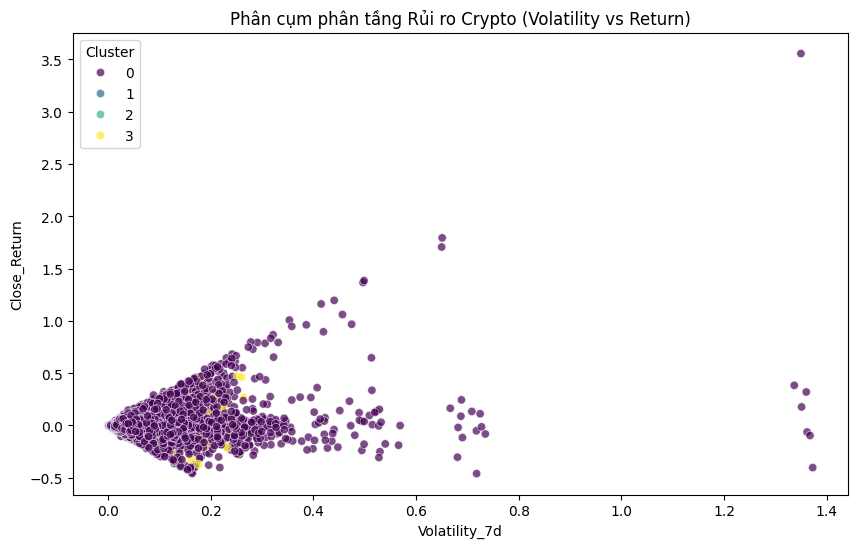

In [2]:
clustered_df, cluster_profiles = run_clustering(featured_df, config)
display(cluster_profiles)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=clustered_df, x='Volatility_7d', y='Close_Return', hue='Cluster', palette='viridis', alpha=0.7)
plt.title('Phân cụm phân tầng Rủi ro Crypto (Volatility vs Return)')
plt.show()

## 2. Phân Lớp xu hướng thị trường (Random Forest Classification)

Bắt đầu Supervised Learning (Phân lớp Classification)...
========= CLASSIFICATION REPORT =========
              precision    recall  f1-score   support

        Down       0.44      0.50      0.47      2751
        Flat       0.39      0.31      0.35      1498
          Up       0.48      0.46      0.47      2639

    accuracy                           0.44      6888
   macro avg       0.44      0.42      0.43      6888
weighted avg       0.44      0.44      0.44      6888

ROC-AUC Score: 0.6149

Feature Importances:
         Feature  Importance
2  Volatility_7d    0.340072
3   Volume_Ratio    0.232448
0    Close_Lag_1    0.214562
1    Close_Lag_3    0.212918


,Feature,Importance
2,Volatility_7d,0.340072
3,Volume_Ratio,0.232448
0,Close_Lag_1,0.214562
1,Close_Lag_3,0.212918


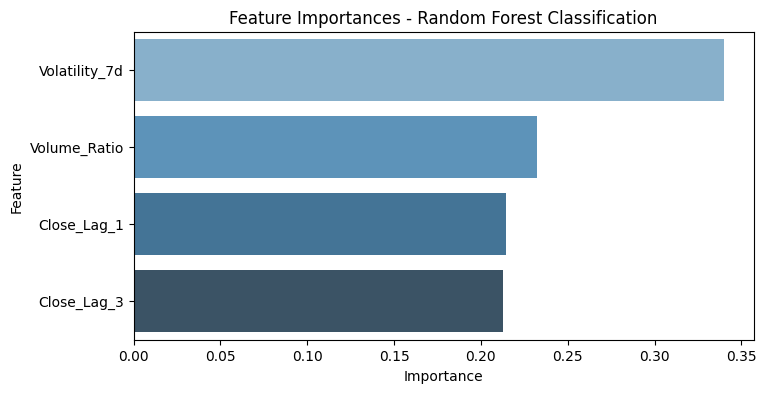

In [3]:
rf_model, feature_importances = run_classification(featured_df, config)
display(feature_importances)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='Blues_d')
plt.title('Feature Importances - Random Forest Classification')
plt.show()